Phase 1: Setup data

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Checks if GPU is turned on
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Define how to prepare the images
transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize all satellite images to 64x64 pixels
    transforms.ToTensor(),       # Convert the image into a mathematical grid (Tensor)
])

# Download the EuroSAT dataset
print("Downloading data...")
dataset = torchvision.datasets.EuroSAT(root='./data', download=True, transform=transform)

# Split the data: 80% for training the AI, 20% for testing it later
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create "DataLoaders" - these feed the images to the AI in batches of 32 at a time
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total images: {len(dataset)}. Ready to go!")

100%|██████████| 94.3M/94.3M [00:01<00:00, 86.8MB/s]


Total images: 27000. Ready to go!


Phase 2: Convolutional Neural Network (CNN)

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class SatelliteClassifier(nn.Module):
    def __init__(self):
        super(SatelliteClassifier, self).__init__()
        # Step 1: Scanning layers (Convolutions)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Step 2: Pooling layer (zooming out/simplifying the image)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Step 3: Decision layers (Linear mapping to the 10 categories)
        # Pooling twice to make 64x64 image become 16x16.
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 10) # 10 is the number of classes in EuroSAT

    def forward(self, x):
        # Path the image takes
        x = self.pool(F.relu(self.conv1(x))) # Scan -> Activate (ReLU) -> Zoom out
        x = self.pool(F.relu(self.conv2(x))) # Scan -> Activate (ReLU) -> Zoom out
        x = x.view(-1, 32 * 16 * 16)         # Flatten the grid into a single line of numbers
        x = F.relu(self.fc1(x))              # Make initial connections
        x = self.fc2(x)                      # Final 10 choices
        return x

# Create the model and send it to the GPU
model = SatelliteClassifier().to(device)
print("Model built successfully!")

Model built successfully!


Phase 3: Training the AI

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader, Dataset
from PIL import Image

# Download base data with no transforms
base_dataset = torchvision.datasets.EuroSAT(root='./data', download=True)

# Split mathematically first (70% Train, 15% Validation, 15% Test)
train_len = int(0.7 * len(base_dataset))
val_len = int(0.15 * len(base_dataset))
test_len = len(base_dataset) - train_len - val_len

train_subset, val_subset, test_subset = random_split(base_dataset, [train_len, val_len, test_len])

# Define strictly seperate transforms
# Training gets "Augmentation" (random flips/rotations) to make the AI robust
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# Val/Test only get resized and normalized. No random flipping.
eval_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create a wrapper to apply transforms safely
class TransformDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x) # Apply transform dynamically
        return x, y

    def __len__(self):
        return len(self.subset)

# Finalize our DataLoaders
train_loader = DataLoader(TransformDataset(train_subset, train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(TransformDataset(val_subset, eval_transforms), batch_size=32, shuffle=False)
test_loader = DataLoader(TransformDataset(test_subset, eval_transforms), batch_size=32, shuffle=False)

print("Data successfully isolated. Leakage mitigated.")

Data successfully isolated. Leakage mitigated.


In [6]:
import torch.optim as optim

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # Training phase
    model.train() # Put model in training mode
    train_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Validation phase
    model.eval() # Put model in evaluation mode (turns off dropouts/gradients)
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad(): # Do not calculate gradients (saves memory)
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # Log metrics
    history['train_loss'].append(train_loss/len(train_loader))
    history['val_loss'].append(val_loss/len(val_loader))
    history['train_acc'].append(100 * correct_train / total_train)
    history['val_acc'].append(100 * correct_val / total_val)

    print(f"Epoch {epoch+1:02d} | Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}%")

Epoch 01 | Train Acc: 71.12% | Val Acc: 76.25%
Epoch 02 | Train Acc: 78.50% | Val Acc: 78.59%
Epoch 03 | Train Acc: 79.90% | Val Acc: 82.20%
Epoch 04 | Train Acc: 81.46% | Val Acc: 78.77%
Epoch 05 | Train Acc: 82.31% | Val Acc: 81.33%
Epoch 06 | Train Acc: 82.96% | Val Acc: 85.53%
Epoch 07 | Train Acc: 84.05% | Val Acc: 85.88%
Epoch 08 | Train Acc: 84.75% | Val Acc: 85.80%
Epoch 09 | Train Acc: 85.75% | Val Acc: 84.17%
Epoch 10 | Train Acc: 86.21% | Val Acc: 86.25%
Epoch 11 | Train Acc: 86.73% | Val Acc: 86.35%
Epoch 12 | Train Acc: 87.58% | Val Acc: 87.01%
Epoch 13 | Train Acc: 87.98% | Val Acc: 84.42%
Epoch 14 | Train Acc: 88.42% | Val Acc: 85.73%
Epoch 15 | Train Acc: 89.11% | Val Acc: 86.74%


Phase 4: Analytics (Graphing the Results)

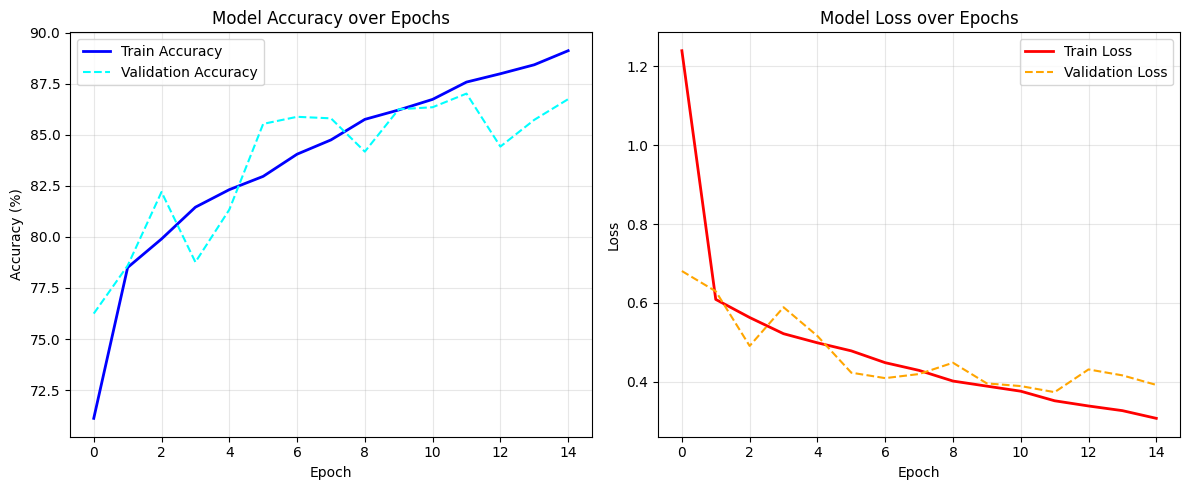

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='cyan', linestyle='--')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Phase 5: Simulating Space Environment Degradation

Clean Data Accuracy: 85.85%
Low Sensor Noise Accuracy: 13.68%
High Sensor Noise Accuracy: 15.80%


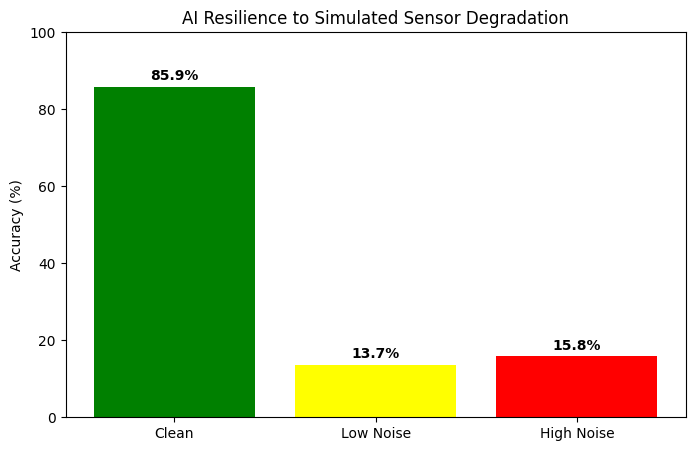

In [8]:
def test_model_with_noise(model, dataloader, noise_factor=0.0):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # Inject simulated radiation/sensor noise
            if noise_factor > 0:
                noise = torch.randn_like(images) * noise_factor
                images = images + noise
                # Keep pixel values within valid math bounds
                images = torch.clamp(images, 0., 1.)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# Run the comparison
clean_accuracy = test_model_with_noise(model, test_loader, noise_factor=0.0)
low_noise_acc = test_model_with_noise(model, test_loader, noise_factor=0.3)
high_noise_acc = test_model_with_noise(model, test_loader, noise_factor=0.7)

print(f"Clean Data Accuracy: {clean_accuracy:.2f}%")
print(f"Low Sensor Noise Accuracy: {low_noise_acc:.2f}%")
print(f"High Sensor Noise Accuracy: {high_noise_acc:.2f}%")

# Graphing the degradation
noise_levels = ['Clean', 'Low Noise', 'High Noise']
accuracies = [clean_accuracy, low_noise_acc, high_noise_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(noise_levels, accuracies, color=['green', 'yellow', 'red'])
plt.title('AI Resilience to Simulated Sensor Degradation')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

Phase 6.1: Setting up the PyTorch "Hooks"

In [9]:
# Need variables to store the wiretapped data
activations = None
gradients = None

# The Forward Hook: Spies on the image as it moves forward through the layer
def forward_hook(module, input, output):
    global activations
    activations = output

# The Backward Hook: Spies on the error/learning signal as it moves backward
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

# Attach the wiretaps to the final convolutional layer (conv2)
# Uses the 'model that was trained in the previous steps
hook_f = model.conv2.register_forward_hook(forward_hook)
hook_b = model.conv2.register_full_backward_hook(backward_hook)

print("Wiretaps successfully attached to conv2!")

Wiretaps successfully attached to conv2!


Phase 6.2: Interrogation

In [10]:
import torch.nn.functional as F
import cv2 # OpenCV for image resizing

# Helper function to revert our mathematical color changes for human viewing
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1) # Keep pixel values valid

# Grab one batch of images from the test set
images, labels = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device) # Isolate just the first image
actual_label = labels[0].item()

# Put the model in evaluation mode. Must allow gradients for Grad-CAM
model.eval()
img.requires_grad_(True)

# Forward pass: Make a guess
output = model(img)
predicted_class = output.argmax(dim=1).item()
confidence_score = output[0, predicted_class]

# Backward pass: Trace the reasoning backwards
model.zero_grad() # Clear old math
confidence_score.backward() # Run the math in reverse!

print(f"AI predicted class ID {predicted_class} (Actual was {actual_label})")

AI predicted class ID 4 (Actual was 4)


Phase 6.3: Generating the Heatmap

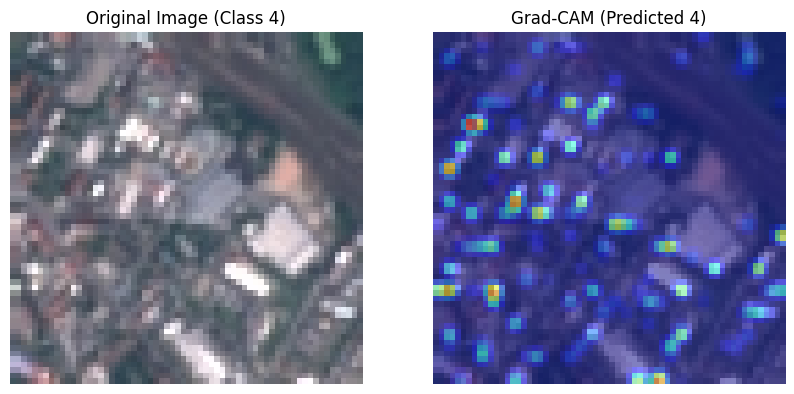

In [11]:
# Pool the gradients across the spatial dimensions
# This creates a single "importance" number for each of the 32 filters in the conv2 layer
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

# Weight the activations by their importance
# Turning up the brightness on the filters that mattered most
for i in range(activations.size(1)):
    activations[:, i, :, :] *= pooled_gradients[i]

# Create the Heatmap
heatmap = torch.mean(activations, dim=1).squeeze()
heatmap = F.relu(heatmap) # keep postive influence, discard negative (ReLU)
heatmap /= torch.max(heatmap) # Normalize to a scale of 0 to 1

# Format the heatmap for matplotlib
heatmap = heatmap.cpu().detach().numpy() # Move off GPU to normal memory
heatmap = cv2.resize(heatmap, (64, 64))  # Resize back to original image size (64x64)

# Get the original image ready to show
original_img = unnormalize(img.squeeze()).cpu().detach().permute(1, 2, 0).numpy()

# Plotting the results
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Original Image (Class {actual_label})")
plt.axis('off')

# Grad-CAM Overlay
plt.subplot(1, 2, 2)
plt.imshow(original_img)
plt.imshow(heatmap, cmap='jet', alpha=0.5) # alpha=0.5 makes it transparent
plt.title(f"Grad-CAM (Predicted {predicted_class})")
plt.axis('off')

# Clean up the wiretaps so they do not slow down the model later
hook_f.remove()
hook_b.remove()

plt.show()